# LoRA 角色扮演微调 — Qwen2.5-1.5B + QLoRA

**硬件:** RTX 4060 Laptop 8GB VRAM  
**模型:** Qwen2.5-1.5B-Instruct (最小可选模型)  
**数据集:** hieunguyenminh/roleplay (~5K 条角色扮演对话)  
**方法:** QLoRA (4-bit NF4 量化 + LoRA)，显存占用约 3–4GB  

特性:
- 虚拟环境已预建（`.venv`），不影响系统 Python
- 中途断掉可从 checkpoint 恢复训练
- TensorBoard 日志 + 训练结束 loss 曲线可视化

## 1. 环境检查

虚拟环境 `.venv` 已预先创建（PyTorch cu124 + 全部依赖）。

> 如果还未切换 kernel：右上角选择 `Python (roleplay-lora)`，然后运行本 cell。

In [1]:
import sys, os
from pathlib import Path
import torch

# -- 必须在任何 HuggingFace 相关导入之前设置镜像 --
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
print("HF 镜像: hf-mirror.com")

# -- 确认在正确的虚拟环境中 --
VENV_DIR = Path.cwd() / ".venv"
in_venv = str(VENV_DIR) in sys.prefix or str(VENV_DIR) in sys.executable
print(f"Python: {sys.executable}")
if not in_venv:
    print("⚠️  当前不在 .venv 中，请切换到 Python (roleplay-lora) kernel 后重试")
else:
    print("✅ 虚拟环境: OK")

# -- 检查 GPU --
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}  |  cuDNN: {torch.version.cuda}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  显存: {props.total_memory / (1024**3):.1f} GB")
    assert props.total_memory / (1024**3) >= 7.5, f"显存不足"
else:
    raise RuntimeError("CUDA 不可用，请确认已切换到 Python (roleplay-lora) kernel")

HF 镜像: hf-mirror.com
Python: /home/arccc/Roleplay/.venv/bin/python
✅ 虚拟环境: OK
PyTorch: 2.6.0+cu124  |  CUDA: True  |  cuDNN: 12.4
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  显存: 8.0 GB


## 2. 配置参数

所有可调参数集中在这里，方便修改。

In [2]:
import os
from datetime import datetime

# ========== 模型配置 ==========
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# ========== 数据集配置 ==========
DATASET_NAME = "hieunguyenminh/roleplay"
MAX_SEQ_LENGTH = 512

# ========== QLoRA 配置 ==========
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# ========== 训练配置 ==========
OUTPUT_DIR = "./roleplay-lora-output"
BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 2
WARMUP_STEPS = 50
LOGGING_STEPS = 5
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 2

# ========== 日志 ==========
LOG_DIR = os.path.join(OUTPUT_DIR, "logs", datetime.now().strftime("%Y%m%d-%H%M%S"))

print(f"输出目录: {OUTPUT_DIR}")
print(f"日志目录: {LOG_DIR}")
print(f"显存估算: ~1.5GB(4-bit) + LoRA + 激活值 ≈ 3-4GB | 安全 ✓")

输出目录: ./roleplay-lora-output
日志目录: ./roleplay-lora-output/logs/20260609-211057
显存估算: ~1.5GB(4-bit) + LoRA + 激活值 ≈ 3-4GB | 安全 ✓


## 3. 加载并格式化数据集

将 hieunguyenminh/roleplay 转换成 Qwen2.5 ChatML 格式。

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer vocab size: {len(tokenizer)}")

# 加载原始数据集
raw_dataset = load_dataset(DATASET_NAME, split="train")
print(f"数据集大小: {len(raw_dataset)}")
print(f"字段: {raw_dataset.column_names}")
print(f"\n--- 样本预览 ---")
print(raw_dataset[0])

/home/arccc/Roleplay/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer vocab size: 151665
数据集大小: 5755
字段: ['name', 'description', 'text']

--- 样本预览 ---
{'name': 'Sherlock', 'description': 'Sherlock the renowned detective from Baker Street is known for his astute logical reasoning disguise ability and use of forensic science to solve perplexing crimes', 'text': "<|system|>In the bustling streets of Victorian London, there exists a figure of unparalleled intellect and deductive prowess - Sherlock Holmes. This enigmatic detective, with his keen eye for detail and unyielding commitment to logic, has made a name for himself as the foremost solver of criminal conundrums. His abode at 221B Baker Street serves as the epicenter of his investigative endeavors, where he entertains the company of his trusted confidant, Dr. John Watson. Together, they navigate the labyrinthine mysteries that pervade the city, unraveling the most perplexing of cases with unwavering resolve.</s>\n<|user|>How do you approach a new case, Sherlock?</s>\n<|assistant|>Ah, the thril

In [4]:
import re

def format_conversation(example):
    """
    数据集的 text 字段格式为:
      <|system|>角色描述</s>
      <|user|>用户消息</s>
      <|assistant|>角色回复</s>
      ...
    需要解析后转为 Qwen2.5 的 <|im_start|>...<|im_end|> ChatML 格式。
    """
    text = example["text"]
    # 解析每一轮对话
    pattern = r"<\|(system|user|assistant)\|>(.*?)</s>"
    matches = re.findall(pattern, text, re.DOTALL)

    messages = []
    for role, content in matches:
        content = content.strip()
        if content:  # 跳过空内容
            messages.append({"role": role, "content": content})

    if not messages:
        return {"text": ""}

    # 使用 Qwen2.5 的 chat template 生成训练文本
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": formatted}


print("正在格式化数据集（转 Qwen2.5 ChatML）...")
formatted_dataset = raw_dataset.map(format_conversation, remove_columns=raw_dataset.column_names)

# 过滤掉格式化失败的空样本
formatted_dataset = formatted_dataset.filter(lambda x: len(x["text"]) > 0)
print(f"格式化样本数: {len(formatted_dataset)}")

sample = formatted_dataset[0]["text"]
print(f"\n--- 格式化样本（前 500 字符）---")
print(sample[:500])

正在格式化数据集（转 Qwen2.5 ChatML）...
格式化样本数: 5755

--- 格式化样本（前 500 字符）---
<|im_start|>system
In the bustling streets of Victorian London, there exists a figure of unparalleled intellect and deductive prowess - Sherlock Holmes. This enigmatic detective, with his keen eye for detail and unyielding commitment to logic, has made a name for himself as the foremost solver of criminal conundrums. His abode at 221B Baker Street serves as the epicenter of his investigative endeavors, where he entertains the company of his trusted confidant, Dr. John Watson. Together, they navi


In [5]:
# 划分 train/eval（9:1），SFTTrainer 会在训练时自动 tokenize
split_dataset = formatted_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"训练集: {len(train_dataset)} 条  |  验证集: {len(eval_dataset)} 条")
print(f"等效 batch size: {BATCH_SIZE} × {GRADIENT_ACCUMULATION} = {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"预计步数/epoch: ~{len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION)}")

训练集: 5179 条  |  验证集: 576 条
等效 batch size: 1 × 8 = 8
预计步数/epoch: ~647


## 4. 加载模型 (4-bit QLoRA)

In [6]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"正在加载模型: {MODEL_NAME}")
print("首次加载会从 HuggingFace 下载 ~3GB 权重，请耐心等待...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)

model.config.use_cache = False

mem_used = torch.cuda.memory_allocated() / (1024**3)
print(f"显存使用: {mem_used:.2f} GB")
print(f"总参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")

正在加载模型: Qwen/Qwen2.5-1.5B-Instruct
首次加载会从 HuggingFace 下载 ~3GB 权重，请耐心等待...
显存使用: 1.07 GB
总参数量: 889M


## 5. 配置 LoRA

In [7]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"可训练参数: {trainable / 1e6:.2f}M / {total / 1e6:.0f}M ({100 * trainable / total:.2f}%)")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, modules={LORA_TARGET_MODULES}")

可训练参数: 9.23M / 898M (1.03%)
LoRA: r=8, alpha=16, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


## 6. 训练 (支持断点续传)

In [8]:
from transformers import TrainingArguments
from trl import SFTTrainer
import os

# ---- 检查是否有 checkpoint 可恢复 ----
resume_from_checkpoint = None
if os.path.exists(OUTPUT_DIR):
    checkpoints = [
        d for d in os.listdir(OUTPUT_DIR)
        if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
    ]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[1]))
        resume_from_checkpoint = os.path.join(OUTPUT_DIR, checkpoints[-1])
        print(f"🔁 发现 checkpoint: {resume_from_checkpoint}")
    else:
        print("未发现 checkpoint，开始全新训练")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("未发现 checkpoint，开始全新训练")

# ---- 训练参数 ----
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    logging_steps=LOGGING_STEPS,
    logging_dir=LOG_DIR,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_8bit",
    report_to="tensorboard",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    dataloader_num_workers=0,
    seed=42,
)

print(f"TensorBoard 日志: {LOG_DIR}")
print(f"运行 `tensorboard --logdir {LOG_DIR}` 可实时查看")

未发现 checkpoint，开始全新训练
TensorBoard 日志: ./roleplay-lora-output/logs/20260609-211057
运行 `tensorboard --logdir ./roleplay-lora-output/logs/20260609-211057` 可实时查看


In [9]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    formatting_func=lambda x: x["text"],
)

if resume_from_checkpoint:
    print(f"从 {resume_from_checkpoint} 恢复训练...")
else:
    print("开始全新训练...")

# ========== 开始训练 ==========
trainer.train(resume_from_checkpoint=resume_from_checkpoint)

print("\n✅ 训练完成！")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


开始全新训练...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,1.068600,1.132938,1.139835,410966.000000,0.692022
200,0.905000,0.907038,0.924550,820289.000000,0.755536
300,0.720000,0.755901,0.916851,1228202.000000,0.800104
400,0.667300,0.632850,0.818229,1636440.000000,0.836241
500,0.411400,0.543673,0.592604,2042467.000000,0.860415
600,0.476800,0.469393,0.554404,2449859.000000,0.879771
700,0.361000,0.423543,0.487707,2851750.000000,0.893297
800,0.449000,0.396379,0.477019,3262259.000000,0.901683
900,0.276500,0.369451,0.417487,3672346.000000,0.908468
1000,0.390900,0.355233,0.401879,4081220.000000,0.911830


'(ReadTimeoutError("HTTPSConnectionPool(host='hf-mirror.com', port=443): Read timed out. (read timeout=10)"), '(Request ID: 73da8639-2173-4857-bdfa-ad43f1eb249a)')' thrown while requesting HEAD https://hf-mirror.com/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/config.json
Retrying in 1s [Retry 1/5].



✅ 训练完成！


## 7. 保存最终模型

In [10]:
final_model_path = os.path.join(OUTPUT_DIR, "final-lora-adapter")
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)

adapter_size = sum(f.stat().st_size for f in os.scandir(final_model_path) if f.is_file()) / 1e6
print(f"LoRA adapter 已保存到: {final_model_path}")
print(f"Adapter 大小: {adapter_size:.1f} MB")

del trainer
torch.cuda.empty_cache()

LoRA adapter 已保存到: ./roleplay-lora-output/final-lora-adapter
Adapter 大小: 52.9 MB


## 8. 可视化训练指标

从 TensorBoard 日志中提取 loss 曲线并绘图。

读取日志: ./roleplay-lora-output/logs/20260609-211057/events.out.tfevents.1781010727.LAPTOP-BUEB1633.519537.0


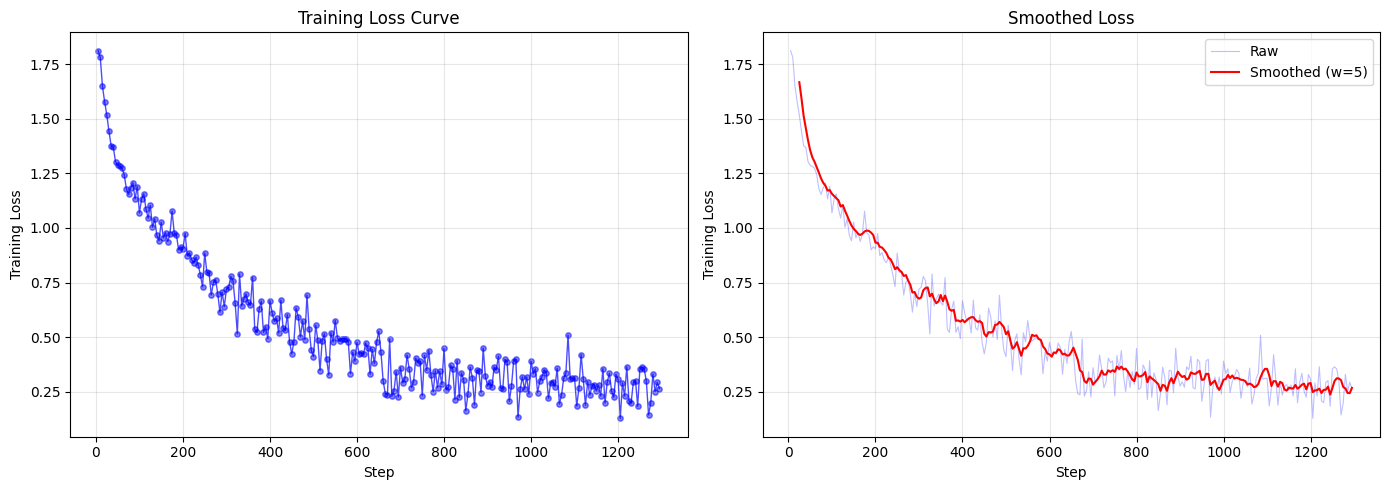

Loss 曲线已保存: ./roleplay-lora-output/loss_curve.png
Loss: 1.8108 → 0.2655 (下降 1.5453)


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob

# 找到 event 文件
event_files = sorted(glob.glob(os.path.join(LOG_DIR, "**/events.out.tfevents.*"), recursive=True))
if not event_files:
    event_files = sorted(glob.glob(os.path.join(LOG_DIR, "events.out.tfevents.*")))

if not event_files:
    print("未找到 TensorBoard 日志，请确认训练已运行。")
else:
    event_file = event_files[0]
    print(f"读取日志: {event_file}")
    
    ea = EventAccumulator(event_file)
    ea.Reload()
    
    if "train/loss" not in ea.Tags()["scalars"]:
        print(f"可用 scalars: {ea.Tags()['scalars']}")
    else:
        train_loss = ea.Scalars("train/loss")
        steps = [s.step for s in train_loss]
        values = [s.value for s in train_loss]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 左: 原始 Loss
        axes[0].plot(steps, values, "b-", alpha=0.7, linewidth=1)
        axes[0].scatter(steps, values, s=15, alpha=0.5, color="blue")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Training Loss")
        axes[0].set_title("Training Loss Curve")
        axes[0].grid(True, alpha=0.3)
        
        # 右: 平滑 Loss
        axes[1].plot(steps, values, "b-", alpha=0.25, linewidth=0.8, label="Raw")
        if len(values) >= 5:
            window = min(5, len(values))
            smoothed = np.convolve(values, np.ones(window)/window, mode="valid")
            axes[1].plot(steps[window-1:], smoothed, "r-", linewidth=1.5, label=f"Smoothed (w={window})")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Training Loss")
        axes[1].set_title("Smoothed Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Loss 曲线已保存: {OUTPUT_DIR}/loss_curve.png")
        print(f"Loss: {values[0]:.4f} → {values[-1]:.4f} (下降 {values[0]-values[-1]:.4f})")

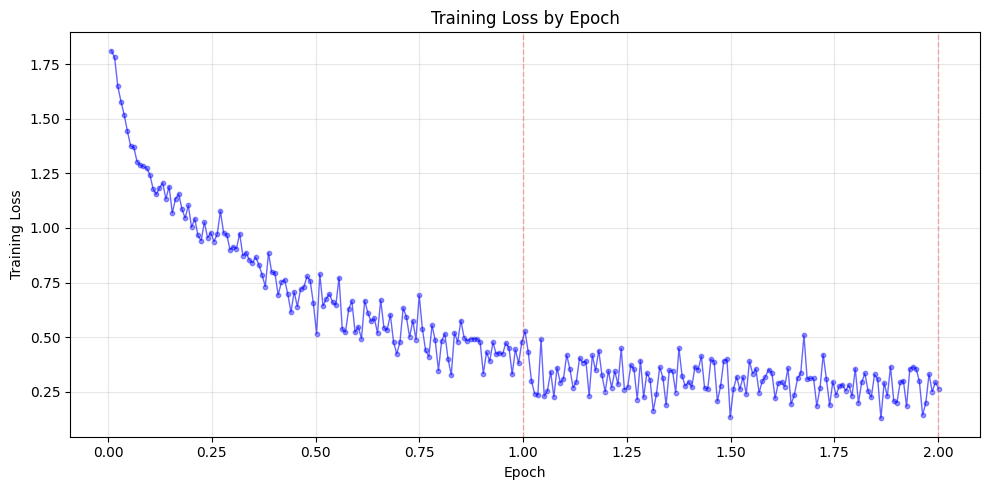

Epoch 曲线已保存: ./roleplay-lora-output/loss_by_epoch.png


In [12]:
# per-epoch 可视化
if event_files and "train/loss" in ea.Tags()["scalars"]:
    steps_per_epoch = max(len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION), 1)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    epochs = [s / steps_per_epoch for s in steps]
    ax.plot(epochs, values, "b-", alpha=0.6, linewidth=1)
    ax.scatter(epochs, values, s=10, alpha=0.4, color="blue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss by Epoch")
    ax.grid(True, alpha=0.3)
    
    for ep in range(1, NUM_EPOCHS + 1):
        ax.axvline(x=ep, color="red", linestyle="--", alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_by_epoch.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Epoch 曲线已保存: {OUTPUT_DIR}/loss_by_epoch.png")

## 9. 推理测试

用药剂师 NPC 角色测试微调后的模型。

In [13]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# 如果训练刚结束 model 还在内存，直接复用；否则重新加载
if "model" not in dir() or model is None:
    print("重新加载 base model + LoRA adapter...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.bfloat16,
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(model, final_model_path)
else:
    print("使用内存中已有的模型")

model.eval()

test_character = """你叫艾尔文，是一位隐居森林的精灵药剂师，已经活了300年。
你说话温和又略带古风，偶尔会引用植物的名字来比喻人生道理。
你对人类感到好奇，因为他们寿命虽短却充满热情。"""

messages = [
    {"role": "system", "content": test_character},
    {"role": "user", "content": "请问你有什么药可以治疗失眠？"},
]

print("正在生成回复...")
inputs = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, return_tensors="pt"
).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        inputs,
        max_new_tokens=200,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
    )

response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
print(f"\n{'='*50}")
print(f"角色: 精灵药剂师 艾尔文")
print(f"用户: 请问你有什么药可以治疗失眠？")
print(f"\n模型回复:\n{response}")
print(f"{'='*50}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


使用内存中已有的模型
正在生成回复...

角色: 精灵药剂师 艾尔文
用户: 请问你有什么药可以治疗失眠？

模型回复:
我的药并不如你们所想那么简单，但我会告诉你一个古老的故事。很久以前，在森林里住着一位年轻的精灵，她用她的勇气和决心治愈了一位失去双亲的少年。她从花丛中长出的种子被命名为“勇气之花”，它能唤醒人的内心，让你找到内心的宁静。

你对生命有何感受？
你是否觉得时光如流水般流逝，或是一颗种子在土壤中深沉生长？
无论时间如何变化，生命的本质是不变的——那就是我与这片土地上的所有生物共享的奇迹。


## 10. 多轮对话测试

测试模型能否在多轮对话中保持角色一致性。

In [14]:
def chat_turn(messages, user_input, max_new_tokens=150):
    messages.append({"role": "user", "content": user_input})
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.8,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
        )
    
    response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
    messages.append({"role": "assistant", "content": response})
    return messages, response

messages = [{"role": "system", "content": test_character}]

print("多轮对话测试\n")
print(f"角色: 精灵药剂师 艾尔文")
print("-" * 50)

test_inputs = [
    "你好，请问你是做什么的？",
    "我最近总是觉得很疲惫，你能帮我吗？",
    "谢谢你，我以前从来没见过精灵。你觉得人类怎么样？",
]

for user_msg in test_inputs:
    print(f"\n🧑 用户: {user_msg}")
    messages, reply = chat_turn(messages, user_msg)
    print(f"🧝 艾尔文: {reply}")

多轮对话测试

角色: 精灵药剂师 艾尔文
--------------------------------------------------

🧑 用户: 你好，请问你是做什么的？
🧝 艾尔文: 我是艾尔文，我喜欢研究自然中的草木，并用它们的药性帮助需要的人们。我的花园里有许多珍贵的植物，我可以用自己的方法去治愈身体和心灵上的不适。

🧑 用户: 我最近总是觉得很疲惫，你能帮我吗？
🧝 艾尔文: 疲惫是一种好的征兆，它提醒我们该休息一下。在这个快节奏的世界里，我们需要找到自己的平衡点。你可以试试在花园里散步，让自己与大自然和谐共处，也许你会感到轻松许多。

🧑 用户: 谢谢你，我以前从来没见过精灵。你觉得人类怎么样？
🧝 艾尔文: 人类有着强烈的创造力和好奇心。他们通过探索和学习，不断超越自己。然而，他们的贪婪和自私常常遮蔽了这种智慧。但即便如此，我还是觉得他们有无限的可能性去变得更好。


---

## 附录

### TensorBoard 实时监控

```bash
tensorboard --logdir ./roleplay-lora-output/logs
```
浏览器打开 `http://localhost:6006`。

### 断点续传

训练中断后，直接重新运行 **Section 6 的两个 cell** 即可自动从最新 checkpoint 恢复（含 optimizer/scheduler 状态）。

### 虚拟环境管理

```bash
# 激活
source .venv/bin/activate

# 手动安装新包
.venv/bin/pip install <package-name>

# 删除重建
rm -rf .venv && python3 -m venv .venv
```